In [1]:
# lab Exam 7

In [2]:
# Q1 , Q2

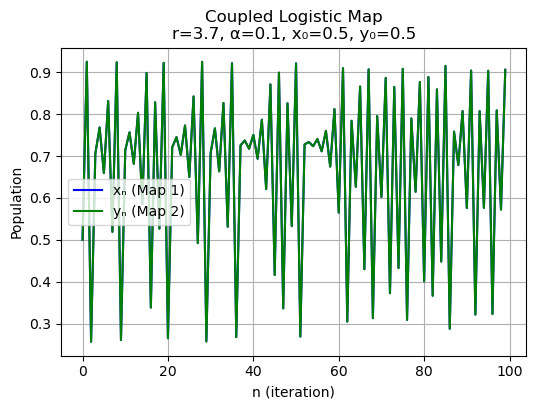

In [14]:
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
import numpy as np

def plot_logistic():
    try:
        r = float(entry_r.get())
        alpha = float(entry_alpha.get())
        x0 = float(entry_x0.get())
        y0 = float(entry_y0.get())
        N = int(entry_iter.get())

        x = np.zeros(N)
        y = np.zeros(N)
        x[0] = x0
        y[0] = y0

        for n in range(N - 1):
            x[n + 1] = r * x[n] * (1 - x[n]) + alpha * (y[n] - x[n])
            y[n + 1] = r * y[n] * (1 - y[n]) + alpha * (x[n] - y[n])

        ax.clear()
        ax.plot(range(N), x, label='xₙ (Map 1)', color='blue')
        ax.plot(range(N), y, label='yₙ (Map 2)', color='green')
        ax.set_title(f"Coupled Logistic Map\nr={r}, α={alpha}, x₀={x0}, y₀={y0}")
        ax.set_xlabel("n (iteration)")
        ax.set_ylabel("Population")
        ax.legend()
        ax.grid(True)
        canvas.draw()

    except Exception as e:
        ax.clear()
        ax.set_title("Error in input or calculation")
        ax.text(0.5, 0.5, str(e), ha='center')
        canvas.draw()

def clear():
    for entry in [entry_r, entry_alpha, entry_x0, entry_y0, entry_iter]:
        entry.delete(0, tk.END)
    ax.clear()
    canvas.draw()

# GUI Setup
root = tk.Tk()
root.title("Coupled Logistic Map Visualizer")

# Input Fields
tk.Label(root, text="r (Growth Rate):").grid(row=0, column=0, sticky='e')
entry_r = tk.Entry(root, width=10)
entry_r.insert(0, "3.7")
entry_r.grid(row=0, column=1)

tk.Label(root, text="α (Coupling Constant):").grid(row=1, column=0, sticky='e')
entry_alpha = tk.Entry(root, width=10)
entry_alpha.insert(0, "0.1")
entry_alpha.grid(row=1, column=1)

tk.Label(root, text="x₀ (Initial x):").grid(row=2, column=0, sticky='e')
entry_x0 = tk.Entry(root, width=10)
entry_x0.insert(0, "0.5")
entry_x0.grid(row=2, column=1)

tk.Label(root, text="y₀ (Initial y):").grid(row=3, column=0, sticky='e')
entry_y0 = tk.Entry(root, width=10)
entry_y0.insert(0, "0.5")
entry_y0.grid(row=3, column=1)

tk.Label(root, text="Iterations (e.g., 100):").grid(row=4, column=0, sticky='e')
entry_iter = tk.Entry(root, width=10)
entry_iter.insert(0, "100")
entry_iter.grid(row=4, column=1)

# Buttons
tk.Button(root, text="Plot", command=plot_logistic).grid(row=5, column=0, pady=10)
tk.Button(root, text="Clear", command=clear).grid(row=5, column=1)

# Plotting area
fig, ax = plt.subplots(figsize=(6, 4))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().grid(row=6, column=0, columnspan=3, pady=10)

# Start the GUI
root.mainloop()


In [15]:
# Q3,4

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

class BifurcationDiagram:

    def __init__(self, root):
        self.root = root
        self.root.title("Logistic Map Bifurcation Diagram")
        self.root.geometry("1200x800")
        self.root.resizable(True, True)
        self.setup_ui()  # Set up the user interface

    def setup_ui(self):
        style = ttk.Style()
        style.configure('TFrame', background='#f0f0f0')
        style.configure('TLabel', background='#f0f0f0', font=('Arial', 11))
        style.configure('TButton', font=('Arial', 11), padding=6)

        main_frame = ttk.Frame(self.root, padding="15")
        main_frame.pack(fill=tk.BOTH, expand=True)

        self.fig = plt.Figure(figsize=(10, 6), dpi=100)
        self.ax = self.fig.add_subplot(111)

        self.canvas = FigureCanvasTkAgg(self.fig, master=main_frame)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)

        control_frame = ttk.Frame(main_frame)
        control_frame.pack(side=tk.TOP, fill=tk.X, pady=10)

        for i in range(6):
            control_frame.grid_columnconfigure(i, weight=1)

        ttk.Label(control_frame, text="r min:").grid(row=0, column=0, padx=5, pady=5, sticky="w")
        self.r_min_entry = ttk.Entry(control_frame, width=8)
        self.r_min_entry.insert(0, "2.5")
        self.r_min_entry.grid(row=0, column=1, padx=5, pady=5, sticky="ew")

        ttk.Label(control_frame, text="r max:").grid(row=0, column=2, padx=5, pady=5, sticky="w")
        self.r_max_entry = ttk.Entry(control_frame, width=8)
        self.r_max_entry.insert(0, "4.0")
        self.r_max_entry.grid(row=0, column=3, padx=5, pady=5, sticky="ew")

        ttk.Label(control_frame, text="r steps:").grid(row=1, column=0, padx=5, pady=5, sticky="w")
        self.r_steps_entry = ttk.Entry(control_frame, width=8)
        self.r_steps_entry.insert(0, "1000")
        self.r_steps_entry.grid(row=1, column=1, padx=5, pady=5, sticky="ew")

        ttk.Label(control_frame, text="Transient iterations:").grid(row=1, column=2, padx=5, pady=5, sticky="w")
        self.transient_entry = ttk.Entry(control_frame, width=8)
        self.transient_entry.insert(0, "1000")
        self.transient_entry.grid(row=1, column=3, padx=5, pady=5, sticky="ew")

        ttk.Label(control_frame, text="Plot iterations:").grid(row=2, column=0, padx=5, pady=5, sticky="w")
        self.plot_iter_entry = ttk.Entry(control_frame, width=8)
        self.plot_iter_entry.insert(0, "100")
        self.plot_iter_entry.grid(row=2, column=1, padx=5, pady=5, sticky="ew")

        ttk.Label(control_frame, text="Initial x:").grid(row=2, column=2, padx=5, pady=5, sticky="w")
        self.x0_entry = ttk.Entry(control_frame, width=8)
        self.x0_entry.insert(0, "0.5")
        self.x0_entry.grid(row=2, column=3, padx=5, pady=5, sticky="ew")

        button_frame = ttk.Frame(control_frame)
        button_frame.grid(row=3, column=0, columnspan=6, pady=10)

        self.plot_btn = ttk.Button(button_frame, text="Generate Bifurcation Diagram", command=self.plot_bifurcation)
        self.plot_btn.pack(side=tk.LEFT, padx=5)

        self.clear_btn = ttk.Button(button_frame, text="Clear", command=self.clear_plot)
        self.clear_btn.pack(side=tk.LEFT, padx=5)

        self.status = tk.StringVar()
        self.status.set("Ready to generate bifurcation diagram")
        self.status_bar = ttk.Label(main_frame, textvariable=self.status, relief=tk.SUNKEN)
        self.status_bar.pack(side=tk.BOTTOM, fill=tk.X)

    def logistic_map(self, x, r):
        return r * x * (1 - x)

    def plot_bifurcation(self):
        try:
            r_min = float(self.r_min_entry.get())
            r_max = float(self.r_max_entry.get())
            r_steps = int(self.r_steps_entry.get())
            transient = int(self.transient_entry.get())
            plot_iter = int(self.plot_iter_entry.get())
            x0 = float(self.x0_entry.get())

            if not (0 < r_min < r_max <= 4.0):
                messagebox.showerror("Input Error", "r_min must be < r_max and both in (0, 4.0]")
                self.status.set("Error: Invalid r range.")
                return
            if r_steps <= 0 or transient <= 0 or plot_iter <= 0:
                messagebox.showerror("Input Error", "Iteration values must be positive.")
                self.status.set("Error: Invalid iteration values.")
                return
            if not (0 <= x0 <= 1):
                messagebox.showerror("Input Error", "Initial x must be in [0, 1]")
                self.status.set("Error: Invalid x0 value.")
                return

            self.status.set("Generating diagram...")
            self.root.update_idletasks()

            r_values = np.linspace(r_min, r_max, r_steps)
            x_values_to_plot = np.zeros((r_steps, plot_iter))

            for i, r in enumerate(r_values):
                x = x0
                for _ in range(transient):
                    x = self.logistic_map(x, r)
                for j in range(plot_iter):
                    x = self.logistic_map(x, r)
                    x_values_to_plot[i, j] = x

            self.ax.clear()
            for i in range(r_steps):
                self.ax.plot([r_values[i]] * plot_iter, x_values_to_plot[i, :],
                             ',k', markersize=0.2, alpha=0.25)

            self.ax.set_xlabel("r")
            self.ax.set_ylabel("Stable population values")
            self.ax.set_title(f"Bifurcation Diagram ({r_min} \u2264 r \u2264 {r_max})")
            self.ax.grid(True, alpha=0.2)

            self.canvas.draw()
            self.status.set(f"Generated diagram with {r_steps} r values")

        except ValueError as e:
            messagebox.showerror("Input Error", f"Invalid input: {e}")
            self.status.set("Error: Invalid input.")
        except Exception as e:
            messagebox.showerror("An Error Occurred", f"Unexpected error: {e}")
            self.status.set(f"Unexpected error: {e}")

    def clear_plot(self):
        self.ax.clear()
        self.ax.grid(True)
        self.canvas.draw()
        self.status.set("Plot cleared")

if __name__ == "__main__":
    root = tk.Tk()
    app = BifurcationDiagram(root)
    root.mainloop()


In [36]:
# Q3 